# Principle Component Analysis Statistical Arbitrage
This strategy attempts to decompose the returns of the whole market into key market and sector factors, and then trades the residual idiosyncratic returns, assuming that they are mean reverting. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller
from itertools import product

# Import data
df = pd.read_csv("prices.txt", delim_whitespace=True)

# Create final hold out for 150 days
hold_out = df.iloc[752:1001]
df_prices = df.iloc[:751]

# Create returns data
returns = df_prices.pct_change()
returns = returns.dropna()


/var/folders/ny/pgx1yx0d5p5d6bxnkllv_jz40000gn/T/ipykernel_5871/3984218428.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("prices.txt", delim_whitespace=True)


In [2]:
# Create standard scaler object
scaler = StandardScaler()
scaler.set_output(transform="pandas")

# Standardise returns
sreturns = scaler.fit_transform(returns)
sreturns = sreturns.dropna()
sreturns.head()

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,SMAH,NPCK,MSDP,EORC,CUBO,HRET,ANSO,DIHO,RTTH,SPLZ,NWIG,MMBT,MDGI,AGVF,RRES,CTGI,ALUT,ACAC,SRTX,GARI,RCRI,ACIX,CCNS,MTNS,IHOZ,NAYO,FWWG,EELT,HRND,AETS,ULXY,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
1,-1.466360,-1.647858,0.392735,-0.416676,-1.210257,-1.588912,-0.364526,-1.109624,-1.984227,-1.184017,-0.716873,-1.382498,0.045672,0.170922,-0.692933,-0.386981,-0.088426,-0.360273,-0.408700,-0.542743,-0.030386,-1.177785,-0.684198,-0.534354,-0.932058,-0.863675,0.216189,0.552818,-1.227334,-0.337836,-0.038760,-0.840124,0.690094,-2.098334,-1.051759,0.150746,0.498374,0.468866,-1.361420,-1.113225,-0.873511,0.848705,-0.327869,-1.433848,-0.475011,-2.494601,-2.082240,-1.465287,-1.671729,-0.575070,-0.763104
2,-0.647942,-0.082120,-0.929618,-0.131994,-1.011231,-1.009759,0.310998,-0.378619,0.743787,0.013958,-0.651139,-0.186208,-1.024654,-0.331943,-0.480775,1.258868,0.039974,1.047487,0.129850,-0.532007,-1.385637,-1.810876,-2.171185,-0.069788,-0.490184,0.475624,0.134759,-1.484832,-0.664557,1.097655,-0.430489,0.530612,0.398399,0.830538,-0.032136,-0.785799,0.565487,0.087780,-0.169673,-1.070192,1.162385,0.841231,-0.053166,-0.696276,-0.426704,0.751611,-1.913027,-1.828766,-0.420218,-2.377674,1.033273
3,0.194304,-0.179808,1.583012,0.232509,1.794451,0.254023,-0.687838,-1.121880,0.372888,0.440178,0.514638,0.724454,-0.533973,-0.898545,-0.995598,0.135238,0.074860,0.527506,-0.491443,-0.469841,0.395010,1.264645,-0.781865,-0.124618,-0.250515,1.383529,-0.938723,0.426521,-0.506209,-0.500817,0.302071,-1.509642,-0.536759,-0.666483,0.346006,-0.373423,0.944980,1.750595,0.628142,1.066497,0.012813,-0.805684,-0.080811,-0.032327,-2.165354,0.997153,0.219651,-1.091620,-1.349410,0.186364,1.010426
4,1.108536,0.685071,1.362108,1.972230,0.089920,0.205743,0.415265,2.051248,0.688209,1.306260,0.258872,0.211655,1.543829,0.086281,-0.725309,0.277860,-0.099924,-0.465419,0.027495,2.098113,-0.035772,-0.120839,0.148291,0.727601,0.408832,-0.031138,0.739370,1.572646,0.705020,1.853325,0.154940,0.198029,0.569851,1.098744,1.975243,-0.559233,-1.011351,-0.114557,-0.414474,0.148723,1.039280,1.498673,0.361287,0.073601,1.194067,1.688568,1.224270,1.765399,1.221805,-0.452035,-0.704139
5,-0.466786,-1.241564,-0.576323,-0.103410,-0.471307,-1.193562,-1.041708,-1.323772,0.035390,-0.905751,0.623519,-0.434709,-1.374014,0.631242,-2.454122,-1.722781,0.645825,0.258812,0.235078,1.182808,-0.515921,-1.146343,-0.051109,-0.663897,-0.193979,-0.046033,1.673235,-0.523834,0.899543,-0.294801,-0.352809,0.046004,-0.518342,1.461940,0.039082,-0.016179,-0.381568,-0.377952,0.198258,0.723105,-1.402068,1.212798,-1.098971,-0.561093,0.312165,0.790420,-0.291315,-0.677644,-0.112346,-0.540493,0.850072


Next, an initial guess for the amount of components to include in the initial run of the strategy. Some key PCA component numbers to try include 1, 5, 10, 15, 20 and 30 through our walk-forward validation.

We don't require enough PCAs to explain 80% of the variance. Forcing PCA to explain 80% via 30 components mean using ~60% of assets as factors, which absorbs tradeable idiosyncratic risk into the factor model, and an overfitting risk too. 

As an aside, it makes sense that PC1 only explains ~20% of variance as ALGO shows high correlation with a basket of the other 50 securites. Idiosyncratic noise cancels out across 49 largely-independent names, so the average tracks the factor almost perfectly, even though no single instrument's own variance is factor-dominated (e.g. an instruments variance is dominated by ALGO).

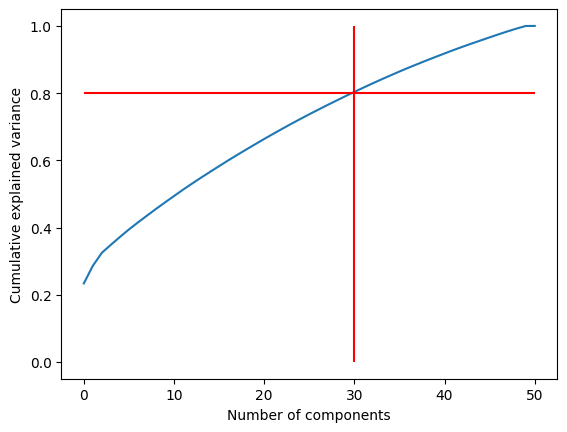

In [3]:
# Run PCA on the data to get an initial guess of an appropriate amount of components
pca_test_comps = PCA().fit(sreturns)

plt.plot(np.cumsum(pca_test_comps.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.hlines(y = 0.8, xmin = 0, xmax=50, colors='red')
plt.vlines(x = 30, ymin=0, ymax=1, colors='red')
plt.ylabel('Cumulative explained variance')
plt.show()


Now, building the actual strategy. Refer to pca_apporach.ipynb for some more in depth. Use a 252 day training period and a 60 test period, done on a rolling window of fixed size for walk-forward validation.

In [ ]:
def pca_stat_arb(train_data, test_data, params):  
  n_components, s_threshold = params
  
  # Fit pca
  pca = PCA(n_components=n_components).fit(train_data)
  
  # Extract factor loadings (Eigenvectors): shape (n_components, n_assets):
  loadings = pca.components_ # loadings_{ij} of loadings_j shows how much each original variable is exposed to component i
  
  # Calculating factor returns from our returns - multiplying them by factor weights
  factor_returns = np.dot(test_data, loadings.T)
  
  # Reconstruct the expected test returns attributable to the factors: R_expected = F * W
  expected_returns = np.dot(factor_returns, loadings)

  # Calculate residual, idiosyncratic risk (residuals = actual - factor)
  residuals = test_data  - expected_returns
  
  # Next, need to model the mean-reversion of residuals, then extract standardised score and half-life. Need to fit factor loadings on rolling basis
  

In [ ]:
class StatArb:
  def __init__(self, vol_span, k_components, z_stop_multiplier = 1.5, time_stop_multiplier = 3, num_assets = 51, algo_idx = 0, fit_window = 252, mr_window = 60, max_half_life = 10, min_half_life = 1, z_entry = 1.75, z_exit = 0.75) :
    # Initial variables, and hardcoded variables
    self.vol_span = vol_span
    self.k_components = k_components
    self.num_assets = num_assets
    self.algo_idx = algo_idx
    self.fit_window = fit_window
    self.mr_window = mr_window
    self.max_half_life = max_half_life # max half_life to open trades for
    self.min_half_life = min_half_life
    self.z_entry = z_entry
    self.z_exit = z_exit
    self.z_stop_multiplier = z_stop_multiplier # hard stop - exit if |z| gros past entry |z| * this
    self.time_stop_multiplier = time_stop_multiplier # time stop - exit if held > this * half_life at entry
    self.signals = np.zeros(self.num_assets)
    self.days_held = np.zeros(self.num_assets) # consecutive days each position has been open
    self.entry_z = np.zeros(self.num_assets) # z-score when position was opened
    self.entry_half_life = np.zeros(self.num_assets) # half_life at the moment a position was opened
    
  # Standardise returns for PCA
  def _standardise_returns(self, returns_df):
    rolling_std = returns_df.ewm(span = self.vol_span).std()
    rolling_std = rolling_std.replace(0, np.nan).fillna(method = 'bfill')
    std_returns = returns_df / rolling_std
    
    return std_returns
      
  # Run PCA and calculate residuals
  def _extract_residuals(self, std_returns):
    # Train PCA
    pca = PCA(n_components=self.k_components)
    factors = pca.fit_transform(std_returns)
    
    # Construct systematic returns
    systematic_returns = pd.DataFrame(
      pca.inverse_transform(factors),
      index = std_returns.index,
      columns = std_returns.columns
    )
    
    daily_residuals = std_returns - systematic_returns
    
    return daily_residuals.cumsum()
  
  # Calculate z-score and check it is stationary
  def _analyse_ou_process(self, series):
    # Use only the last 60 days
    series = series.iloc[-self.mr_window:].dropna()
    
    # Ensure minimum length 
    if len(series)< max(20, self.mr_window // 2):
      return None # not enough data to trus the fit
    
    y = series.values[1:]
    x = series.values[:-1]
    
    # Fit AR(1): X_t = a + b * X_{t-1} + zeta
    b, a = np.polyfit(x, y, 1) # linear regression on residuals
    
    # Discard explosive or random walk rpcesses
    if b <= 0 or b >= 1:
      return None # explosive / unit-root / oscillating - discard
    
    half_life = -np.log(2) / np.log(b)
    
    # Stationarity test (adfuller)
    adf_stat , p_value, _, _, _, _ = adfuller(series)
    is_stationary = p_value < 0.05
    
    # Z-score calculation
    zeta = y - (a + b * x)
    zeta_var = np.var(zeta)
    eq_var = zeta_var / (1 - b**2)
    eq_mean = a / (1 - b)
    
    current_z = (series.iloc[-1] - eq_mean) / np.sqrt(eq_var)
    
    return {
      'half_life': half_life,
      'p_value': p_value,
      'is_stationary': is_stationary,
      'eq_mean': eq_mean,
      'eq_std': np.sqrt(eq_var),
      'current_z': current_z
    }
    
  # Helped so ervery exit path resets state identically
  def _close_position(self, global_i):
    self.signals[global_i] = 0
    self.days_held[global_i] = 0
    self.entry_z[global_i] = 0
    self.entry_half_life[global_i] = 0
    
  # Generate signal for use
  def signal(self, prices):
    """ 
      prices: (nInst, nDays) array. Returns a length -nInst signal array - 0 for ALGO (excluded from factor univerise), 
      0 for instruments with insufficient data or a ressidual that fails stationarity / half-life screen
      and a continuous conviction score (sign-preserving, scaled by distance past z_entry) for everything else
    """     
    
    n_inst, n_days = prices.shape
    
    if n_days < self.fit_window + 1:
      return self.signals # guard for early days
    
    other_idx = [i for i in range(n_inst) if i != self.algo_idx] # return other indicies
    window = prices[other_idx][:, -self.fit_window:]
    
    # Preserve all asset names in data set
    col_labels = [str(i) for i in range(len(other_idx))]
    returns_df = pd.DataFrame(window.T, columns = col_labels).pct_change().dropna()
    
    # Standardise returns and get residuals
    std_returns = self._standardise_returns(returns_df)
    cum_residuals = self._extract_residuals(std_returns)
    
    # Get stationarity statistics of residuals
    for local_i, global_i in enumerate(other_idx):
      col = str(local_i)
      in_position = self.signals[global_i] != 0

      if col not in cum_residuals.columns:
        if in_position:
          self._close_position(global_i) # exit: lost the ability to price this residual at all
        continue
      
      stats = self._analyse_ou_process(cum_residuals[col])
      if stats is None:
        if in_position:
          self._close_position(global_i) # exit: OU fit broke down (explosive / unit-root / too little data)
        continue

      if not (stats["is_stationary"]
              and self.min_half_life <= stats["half_life"] <= self.max_half_life):
        if in_position:
          self._close_position(global_i) # exit: residual no longer passes the stationarity / half-life screen
        continue
      
      # Get z scores
      z = stats["current_z"]

      if in_position:
        self.days_held[global_i] += 1 # one more day survived in this trade

        # hard stop-loss - spread has diverged further past where we entered, cut it
        if abs(z) > abs(self.entry_z[global_i]) * self.z_stop_multiplier:
          self._close_position(global_i)
          continue

        # >>> NEW: time stop - held too long relative to this residual's half-life at entry, cut it
        max_hold_days = np.ceil(self.time_stop_multiplier * self.entry_half_life[global_i])
        if self.days_held[global_i] > max_hold_days:
          self._close_position(global_i)
          continue

        # Mean-reversion exit: spread has reverted back inside the exit band
        if abs(z) < self.z_exit:
          self._close_position(global_i)
          continue

        # Still open - hold the position and refresh conviction
        self.signals[global_i] = -np.sign(z) * (abs(z) - self.z_entry)
      else:
        # Entry: only open a new position once |z| clears z_entry
        if abs(z) < self.z_entry:
          continue
        self.signals[global_i] = -np.sign(z) * (abs(z) - self.z_entry)
        self.entry_z[global_i] = z                            # remember entry z for the stop-loss check
        self.entry_half_life[global_i] = stats["half_life"]    # remember entry half-life for the time stop
        self.days_held[global_i] = 0   # reset holding-period counter
      
    # Return signals
    return self.signals
        
    

Walk-forward validation code

In [ ]:
def walk_forward(none):
  none